# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs import EWFS, decode_results, MAJORITY_VOTE, post_select_results
from ewfs.setting import PEEK, REVERSE_2
from ewfs.noise_models import depolarizing_model

## Sanity checks (for majority vote approach)

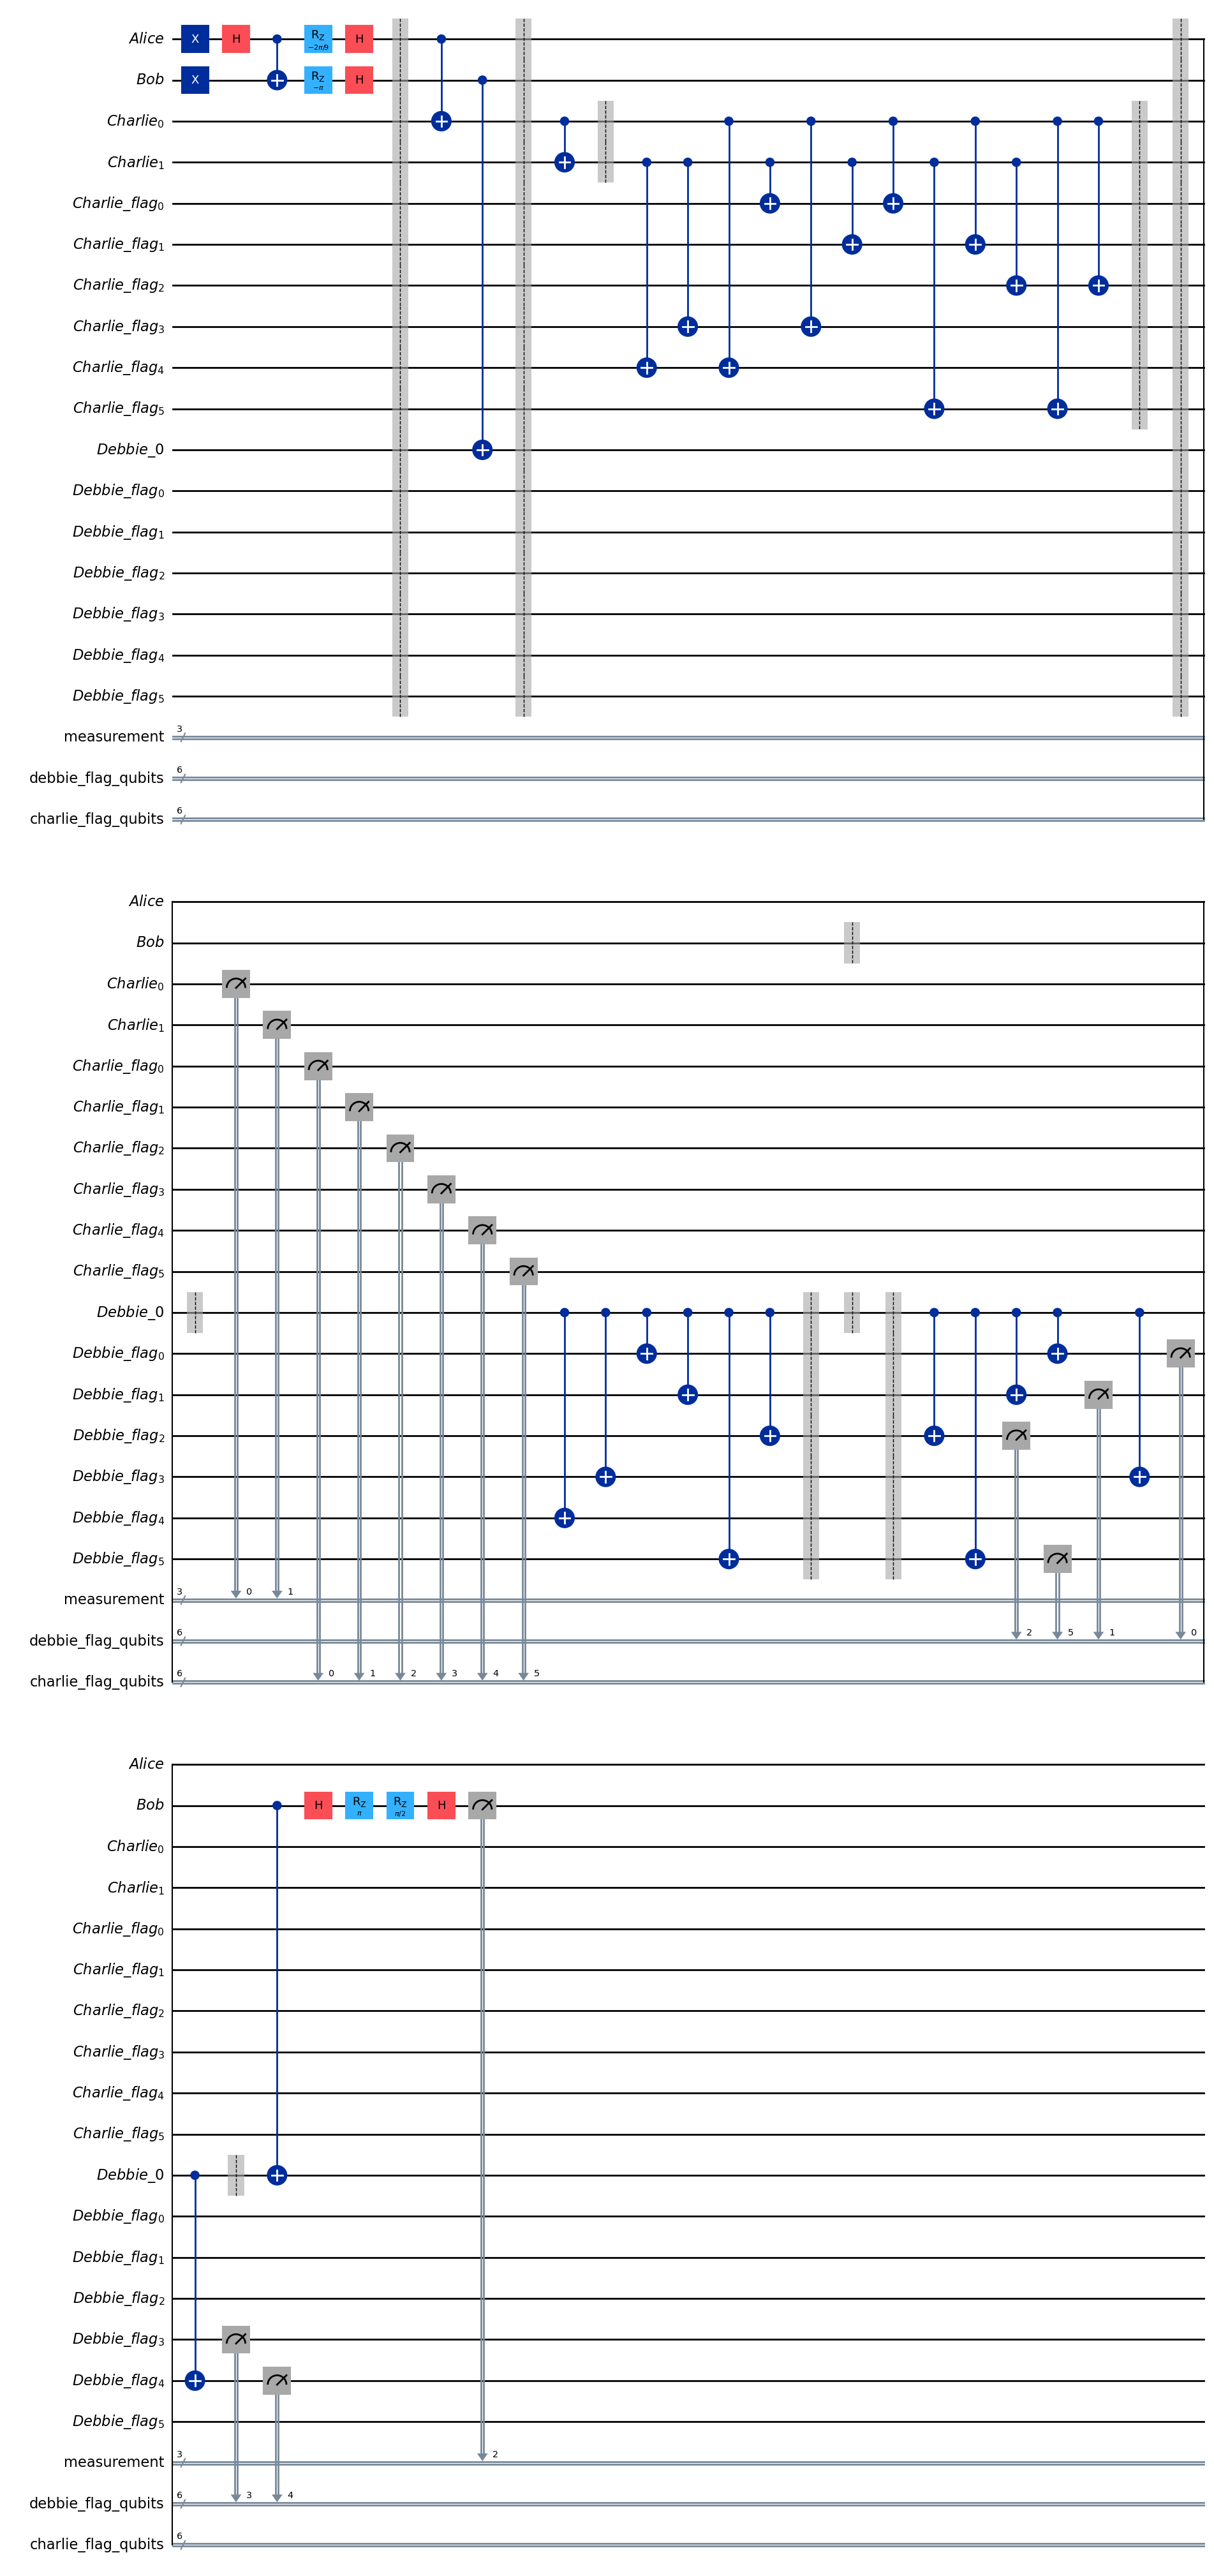

In [2]:
alice_setting = PEEK
bob_setting = REVERSE_2
charlie_size = 2
debbie_size = 1
strategy = MAJORITY_VOTE

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="ghz",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

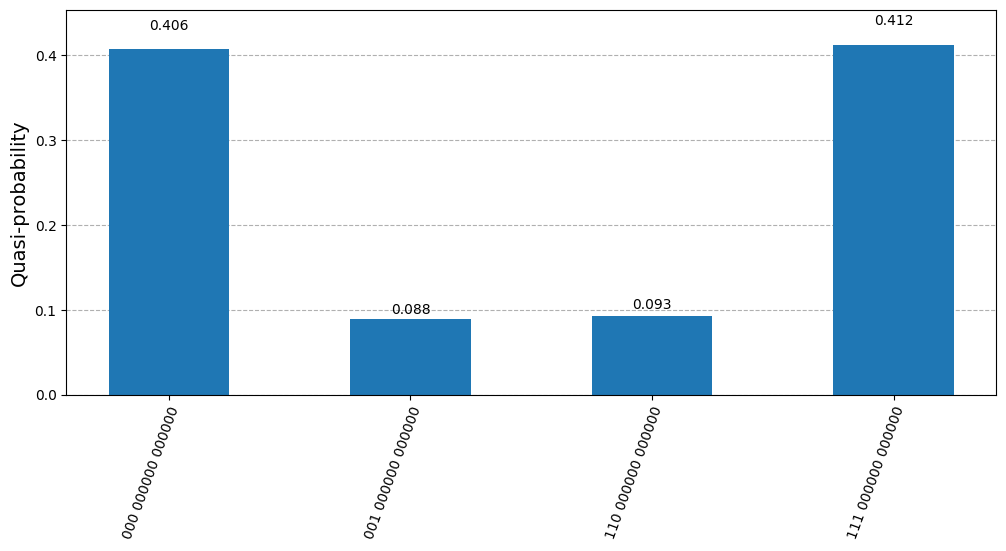

In [3]:
# lots of noise
noise_model = depolarizing_model(circ=qc, single_qubit_error_rate=0.001, two_qubit_error_rate=0.01, meas_error_rate=0.01)
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

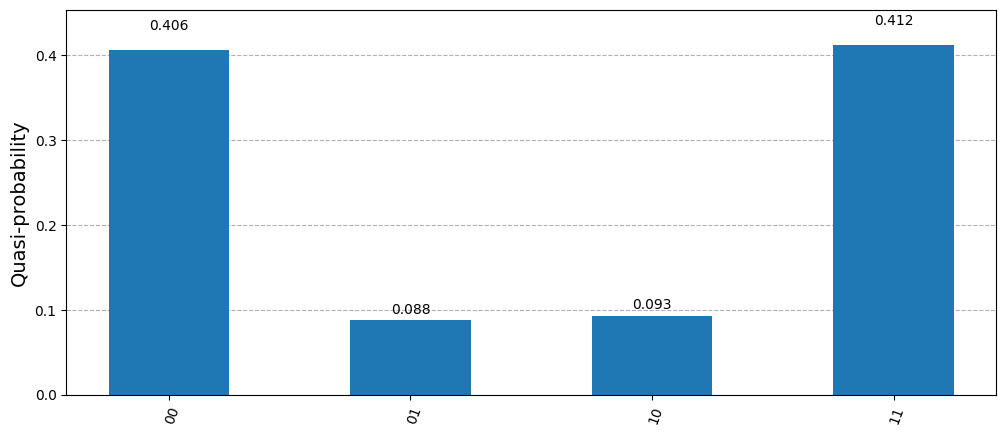

In [ ]:
# Post selecting on th flag qubits and decoding the results
post_selected_probabilities = post_select_results(probabilities, 2, 1, 6, 6)
results = {(alice_setting, bob_setting): post_selected_probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [7]:
from ewfs import run_experiment, SEMI_BRUKNER_SETTINGS

run_experiment(settings=SEMI_BRUKNER_SETTINGS, strategy="random")

Trial 1 out of 2 for task of 1_1
Task with task ID: 7d89728e-c02e-4af3-a5e2-011abe920d8d

Trial 2 out of 2 for task of 1_1
Task with task ID: 65030915-a40a-4ff8-a104-73e2f308c5f2

Trial 1 out of 2 for task of 2_1
Task with task ID: e485e9f5-68b9-4260-ab73-d536cf13bd0d

Trial 2 out of 2 for task of 2_1
Task with task ID: af84d196-7942-4ad1-b20b-be8c5e47c234

Processing trial 1 for task with task ID: 7d89728e-c02e-4af3-a5e2-011abe920d8d
Results: {('peek', 'reverse_1'): {'10': 0.402, '11': 0.0918, '01': 0.4177, '00': 0.0885}, ('peek', 'reverse_2'): {'10': 0.087, '00': 0.4032, '11': 0.4157, '01': 0.0941}, ('reverse_2', 'reverse_1'): {'10': 0.4334, '01': 0.4485, '00': 0.0598, '11': 0.0583}, ('reverse_2', 'reverse_2'): {'10': 0.4445, '01': 0.4396, '11': 0.0553, '00': 0.0606}}
semi_brukner=0.8092000000000006 -- is violated: True
Violations: {'semi_brukner': 0.8092000000000006}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x12f7428e0>, {'1_1': defaultdict(

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_1': defaultdict(list,
                         {'semi_brukner': [0.8092000000000006,
                           0.8177999999999996]}),
             '2_1': defaultdict(list,
                         {'semi_brukner': [0.8195999999999999,
                           0.8216000000000001]})})